In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/raw/Registro A_2.MOV"
cap = cv2.VideoCapture(VIDEO_PATH)

print("Video abierto:", cap.isOpened())
print("Cantidad de frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Ancho:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Alto:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

Video abierto: True
Cantidad de frames: 956
FPS: 29.97804954531201
Ancho: 1920
Alto: 1080


Se carga el video y se selecciona un frame representativo para evaluar los distintos algoritmos de segmentación. El frame se convierte a escala de grises y esta representación facilita la aplicación de los métodos de segmentación.

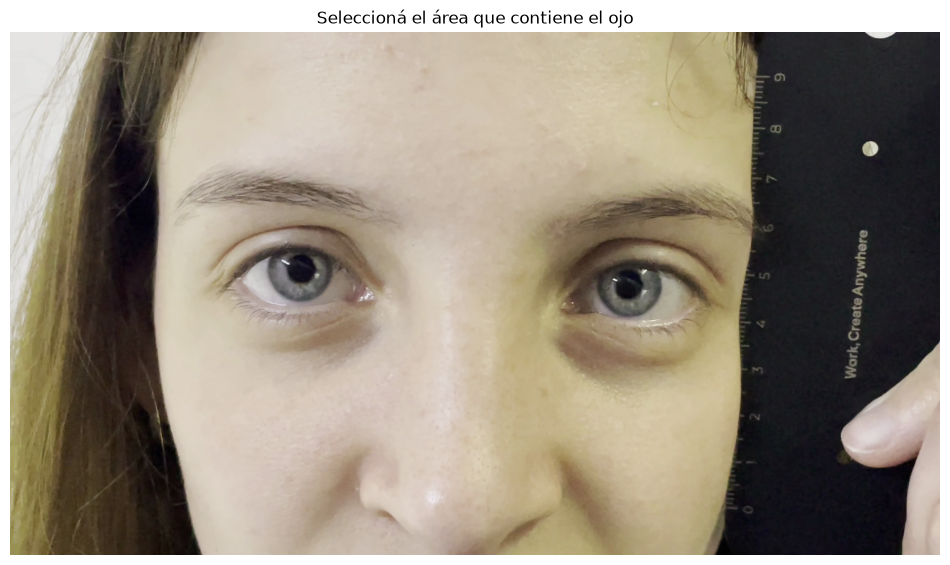

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


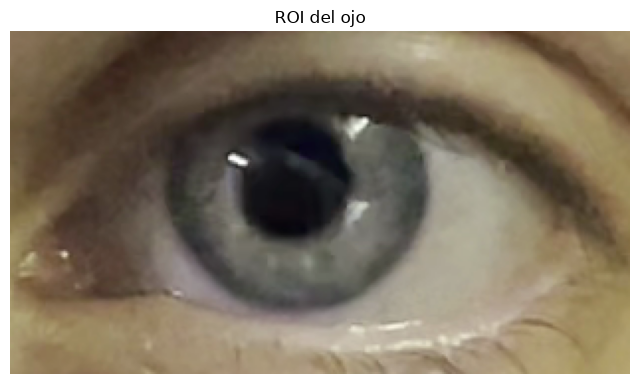

In [33]:
cap = cv2.VideoCapture(VIDEO_PATH)
frame_number = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
ret, frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title("Seleccioná el área que contiene el ojo")
plt.axis("off")
plt.show()

roi = cv2.selectROI(
    "Seleccionar ojo",
    frame,
    fromCenter=False,
    showCrosshair=True
)

x, y, w, h = roi
eye = frame[y:y+h, x:x+w]

cv2.destroyAllWindows()
eye_rgb = cv2.cvtColor(eye, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(eye_rgb)
plt.title("ROI del ojo")
plt.axis("off")
plt.show()

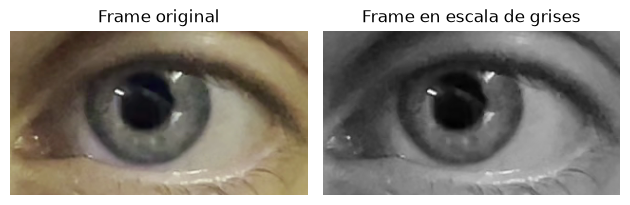

In [35]:
gray = cv2.cvtColor(eye_rgb, cv2.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(eye_rgb)
plt.title("Frame original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Frame en escala de grises")
plt.axis("off")

plt.tight_layout()
plt.show()

Se aplica el método de Otsu para determinar automáticamente un umbral que permita separar la región oscura correspondiente a la pupila del resto de la imagen. Luego se realiza una operación morfológica para eliminar pequeños objetos y suavizar la región segmentada.

Umbral de Otsu: 103.0


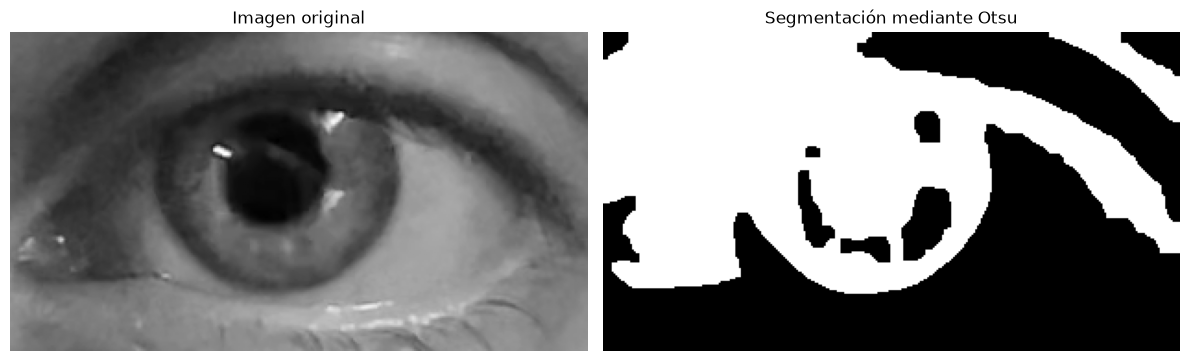

In [36]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

threshold, mask_otsu = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((5, 5), np.uint8)

mask_otsu = cv2.morphologyEx(
    mask_otsu,
    cv2.MORPH_OPEN,
    kernel
)

mask_otsu = cv2.morphologyEx(
    mask_otsu,
    cv2.MORPH_CLOSE,
    kernel
)

print("Umbral de Otsu:", threshold)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_otsu, cmap="gray")
plt.title("Segmentación mediante Otsu")
plt.axis("off")

plt.tight_layout()
plt.show()

Se utiliza el algoritmo K-Means para agrupar los píxeles de la imagen en distintos grupos según sus características de color e intensidad. Se evalúan valores de K entre 2 y 5 para analizar cómo cambia la segmentación de la pupila al aumentar la cantidad de grupos.

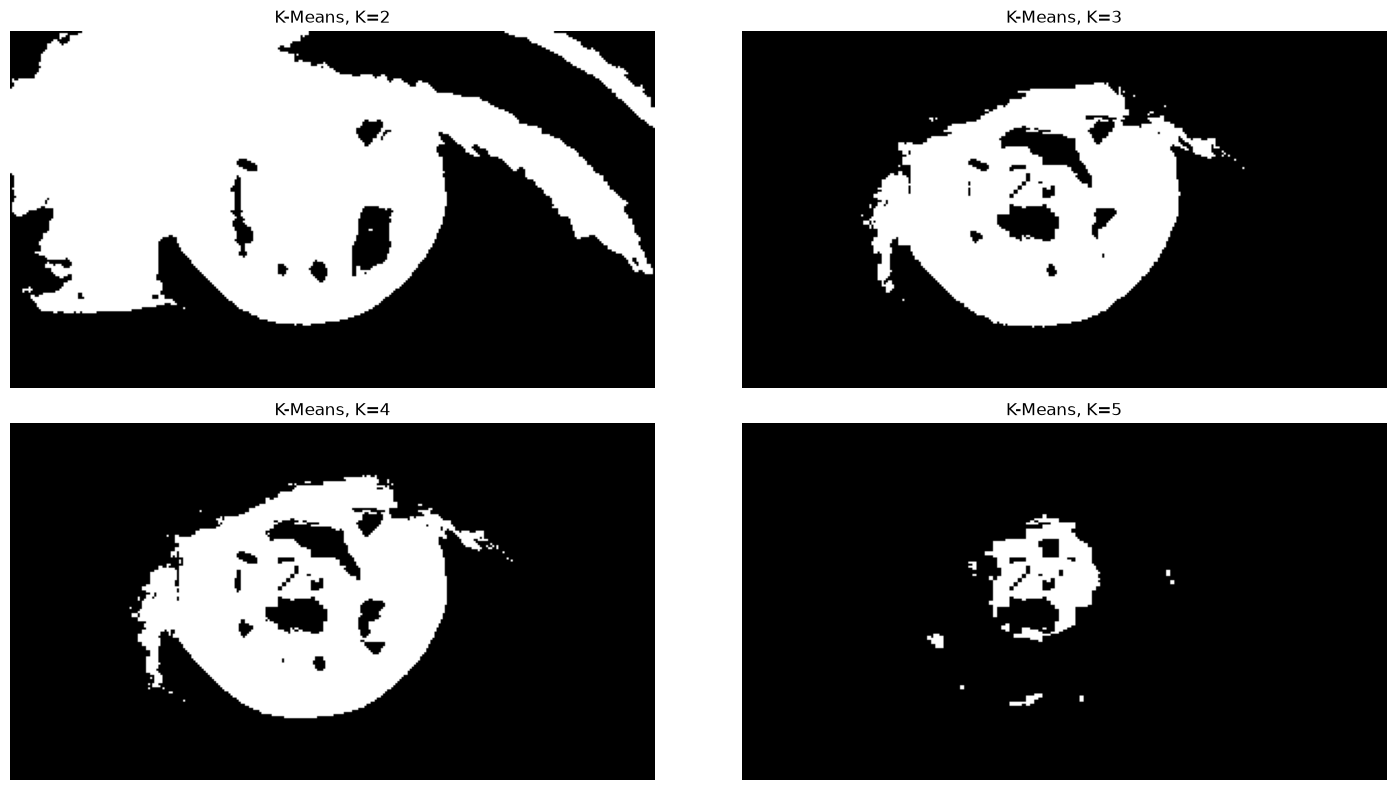

In [ ]:
hsv = cv2.cvtColor(eye_rgb, cv2.COLOR_BGR2HSV)
pixels = hsv.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
results_kmeans = {}

for k in range(2, 6):
    _, labels, centers = cv2.kmeans(pixels,k,None,criteria,10,cv2.KMEANS_PP_CENTERS)

    labels = labels.flatten()
    centers = centers.astype(np.uint8)

    cluster_image = centers[labels]
    cluster_image = cluster_image.reshape(hsv.shape)

    value_image = cluster_image[:, :, 2]

    darkest_cluster = np.argmin(centers[:, 2])

    mask = (labels == darkest_cluster).astype(np.uint8) * 255
    mask = mask.reshape(hsv.shape[:2])

    results_kmeans[k] = mask

plt.figure(figsize=(15, 8))

for i, k in enumerate(range(2, 6)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(results_kmeans[k], cmap="gray")
    plt.title(f"K-Means, K={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Usamos un contorno activo para localizar los bordes de la pupila. Definimos una curva cerrada próxima al borde pupilar y dejamos que evolucione en función de las características de la imagen hasta converger hacia la frontera de la estructura.

In [ ]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

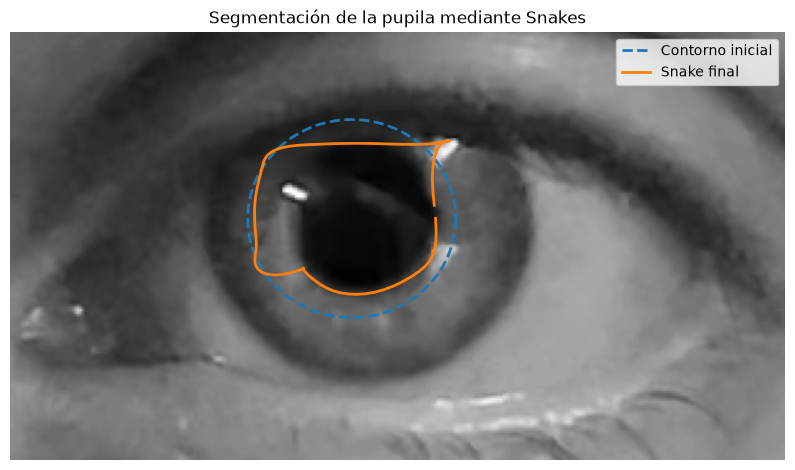

In [ ]:
gray_eye = gray.astype(np.float64) / 255.0
smooth_eye = gaussian(gray_eye, sigma=2)

center_x = 137.5
center_y = 75

# Un poco más grande que la pupila
radius_x = 42
radius_y = 40
theta = np.linspace(0, 2*np.pi, 150)

x = center_x + radius_x * np.cos(theta)
y = center_y + radius_y * np.sin(theta)

init = np.column_stack((y, x))

snake = active_contour(
    smooth_eye,
    init,
    alpha=0.0005,
    beta=0.05,
    gamma=0.1,
    w_line=0.1,
    w_edge=1,
    max_num_iter=1300,
    convergence=0.001
)

plt.figure(figsize=(10, 7))

plt.imshow(gray_eye, cmap="gray")

plt.plot(
    init[:, 1],
    init[:, 0],
    "--",
    linewidth=2,
    label="Contorno inicial"
)

plt.plot(
    snake[:, 1],
    snake[:, 0],
    linewidth=2,
    label="Snake final"
)

plt.title("Segmentación de la pupila mediante Snakes")
plt.legend()
plt.axis("off")
plt.show()

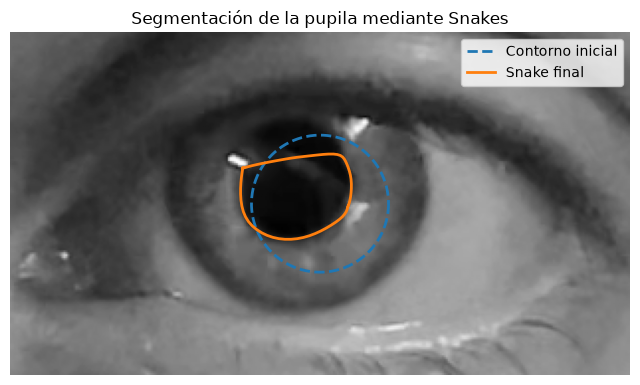

In [86]:
gray_eye = gray.astype(np.float64) / 255.0
smooth_eye = gaussian(gray_eye, sigma=2)
h, w = gray_eye.shape
center_x = w // 2
center_y = h // 2
radius = min(h, w) * 0.2
theta = np.linspace(0, 2 * np.pi, 100)
x = center_x + radius * np.cos(theta)
y = center_y + radius * np.sin(theta)
init = np.array([y, x]).T

snake = active_contour(
    smooth_eye,
    init,
    alpha=0.01,
    beta=0.1,
    gamma=0.01,
    w_line=0,
    w_edge=1,
    max_num_iter=500,
    convergence=0.1
)

plt.figure(figsize=(8, 6))

plt.imshow(gray_eye, cmap="gray")

x_init = init[:, 1]
y_init = init[:, 0]

x_snake = snake[:, 1]
y_snake = snake[:, 0]

plt.plot(x_init, y_init, "--", linewidth=2, label="Contorno inicial")
plt.plot(x_snake, y_snake, linewidth=2, label="Snake final")

plt.title("Segmentación de la pupila mediante Snakes")
plt.legend()
plt.axis("off")
plt.show()